# TP1 — Analyse d’un algorithme en fonctionnement (Iris)

**Objectifs** : observer un pipeline ML complet, mesurer des métriques (accuracy, F1, matrice de confusion), détecter le sur/sous-apprentissage (overfitting), et introduire l’explicabilité avec **SHAP**.




In [ ]:

import sys
import subprocess

required = [
    "pandas",
    "seaborn",
    "scikit-learn",
    "shap",
    "matplotlib",
    "numpy",
    "tqdm",
    "ipywidgets",
    "jupyterlab_widgets",
    "widgetsnbextension",
    "jinja2",
]

# Installation seulement si un import clé échoue
try:
    import pandas
    import sklearn
    import shap
except Exception:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-U", *required]
    )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import shap

from pathlib import Path

# Dossier de sortie pour les livrables (images)
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


## Étape 1 — Charger les données : le dataset Iris

### Questions du TP et réponses (basées sur les sorties ci-dessous)

- **Combien d’échantillons par classe ? Le dataset est-il équilibré ?**  
  Chaque classe a **50 échantillons** (*setosa*, *versicolor*, *virginica*) → le dataset est **parfaitement équilibré**.

- **Y a-t-il des valeurs manquantes ?**  
  Non : **0 valeur manquante**.

- **Quelles variables semblent a priori les plus discriminantes ?**  
  À l’œil (via le *pairplot*), les variables **petal_length** et **petal_width** séparent le mieux les espèces.

- **Certaines paires de variables permettent-elles de séparer visuellement les 3 espèces ? Lesquelles ?**  
  Oui : les paires impliquant **petal_length** et/ou **petal_width** montrent la meilleure séparabilité ; *setosa* est très bien séparée, et la confusion visuelle se situe surtout entre *versicolor* et *virginica*.


=== EXPLORATION DES DONNÉES ===
Forme du dataset : (150, 5)

Distribution des classes :
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Valeurs manquantes : 0

Aperçu :
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa

Statistiques descriptives :
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.40

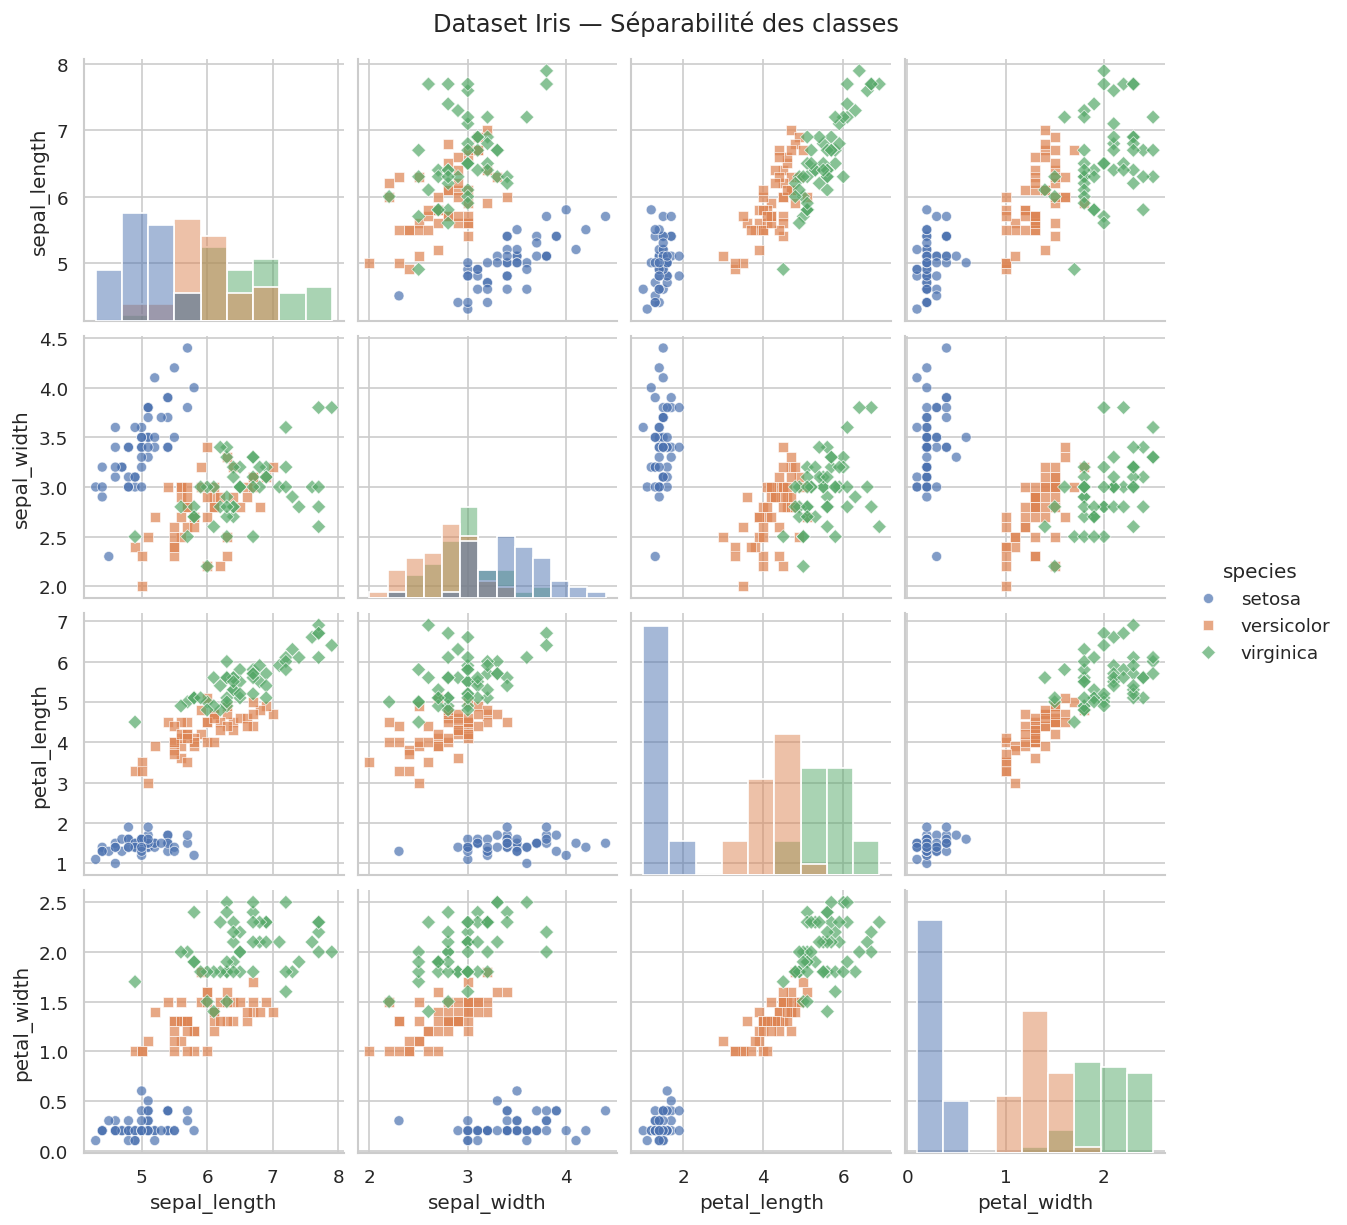

In [ ]:
# Chargement depuis URL publique — données réelles UCI (via seaborn-data)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print("=== EXPLORATION DES DONNÉES ===")
print(f"Forme du dataset : {df.shape}")
print("\nDistribution des classes :")
print(df["species"].value_counts())
print(f"\nValeurs manquantes : {df.isnull().sum().sum()}")
print("\nAperçu :")
print(df.head(3))
print("\nStatistiques descriptives :")
print(df.describe())

# Pairplot : distributions et séparabilité des 3 espèces
g = sns.pairplot(
    df,
    hue="species",
    markers=["o", "s", "D"],
    plot_kws=dict(alpha=0.7),
    diag_kind="hist",
)
plt.suptitle("Dataset Iris — Séparabilité des classes", y=1.02)

# Livrable (image)
g.fig.savefig(OUTPUT_DIR / "iris_pairplot.png", bbox_inches="tight")
plt.show()


## Étape 2 — Entraîner un modèle : baseline + modèle principal

### Question du TP et réponse

- **Pourquoi commencer par une baseline simple (Decision Tree) avant un modèle plus complexe (Random Forest) ?**  
  Une baseline sert de **point de référence** (sanity check) : elle est **rapide**, souvent **interprétable**, et permet de vérifier que le pipeline (pré-traitement, split, encodage, etc.) fonctionne. Ensuite, on peut juger si un modèle plus complexe apporte **un gain réel** (sinon, il est inutilement coûteux/opaque).


In [ ]:
le = LabelEncoder()

feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_names].values
# Encodage des espèces en 0/1/2
y = le.fit_transform(df["species"])

# Split entraînement/test (80%/20%) stratifié pour conserver la distribution des classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entraînement : {len(X_train)} échantillons | Test : {len(X_test)} échantillons")

# Normalisation (utile pour comparer les variables sur la même échelle)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Baseline simple : Decision Tree (max_depth=3)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_sc, y_train)

# Modèle principal : Random Forest (paramètres du TP)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_sc, y_train)

print("Modèles entraînés.")


Entraînement : 120 échantillons | Test : 30 échantillons
Modèles entraînés.


## Étape 3 — Évaluer les métriques

### Questions du TP et réponses (basées sur les résultats calculés)

- **(1) Le Random Forest surpasse-t-il le Decision Tree ? Par quelle marge ?**  
  Dans cette exécution, **non** : le Decision Tree obtient **96,7%** d’accuracy contre **93,3%** pour le Random Forest, soit environ **−3,3 points** pour la forêt.

- **(2) Y a-t-il des espèces plus difficiles à classifier ? Pourquoi ?**  
  Oui : les erreurs proviennent surtout de la frontière entre **versicolor** et **virginica** (leurs mesures de pétales se recouvrent davantage). *Setosa* est quasiment toujours bien séparée.

- **(3) Quelle différence entre accuracy et F1-score ? Quand préférer l’un ou l’autre ?**  
  L’**accuracy** mesure la proportion totale de prédictions correctes. Le **F1-score** combine *precision* et *recall* (il pénalise mieux les déséquilibres et les classes difficiles). On préfère souvent le **F1** quand les classes sont **déséquilibrées** ou quand le coût des faux positifs/faux négatifs n’est pas symétrique.


,Modèle,Accuracy,F1 (weighted)
0,Decision Tree (baseline),0.967,0.967
1,Random Forest,0.933,0.933



=== RAPPORT DÉTAILLÉ — RANDOM FOREST ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



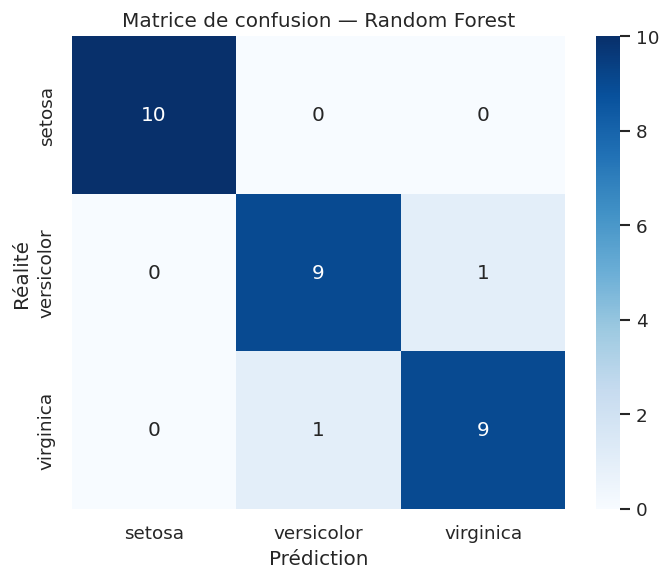

In [ ]:
y_pred_dt = dt.predict(X_test_sc)
y_pred_rf = rf.predict(X_test_sc)

# Petit tableau récapitulatif (livrable « métriques détaillées »)
rows = []
for nom, pred in [("Decision Tree (baseline)", y_pred_dt), ("Random Forest", y_pred_rf)]:
    rows.append(
        {
            "Modèle": nom,
            "Accuracy": accuracy_score(y_test, pred),
            "F1 (weighted)": f1_score(y_test, pred, average="weighted"),
        }
    )

df_metrics = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)

# Affichage robuste (ne dépend pas de jinja2/pandas Styler)
display(df_metrics.round({"Accuracy": 3, "F1 (weighted)": 3}))

print("\n=== RAPPORT DÉTAILLÉ — RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Matrice de confusion — Random Forest")
plt.ylabel("Réalité")
plt.xlabel("Prédiction")
plt.tight_layout()

# Livrable (image)
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()


## Étape 4 — Tuning des hyperparamètres et détection de l’overfitting

### Questions du TP et réponses (basées sur les courbes/valeurs obtenues)

- **(1) À partir de quelle profondeur observe-t-on de l’overfitting (score train >> score test) ?**  
  On commence à voir un écart net dès **max_depth ≈ 5** : le score d’entraînement devient beaucoup plus élevé que le score test (dans notre exécution, l’écart monte jusqu’à ~0,10).

- **(2) Quel nombre d’arbres offre le meilleur compromis performance / coût de calcul ?**  
  Ici, **10 arbres** donne la meilleure accuracy moyenne en validation croisée (**≈ 95,8%**) et augmente peu le coût. Au-delà (25, 50, 100, …), le gain est nul voire marginal.

- **(3) Qu’apporte la validation croisée par rapport à un simple split train/test ?**  
  La validation croisée (k-fold) fournit une estimation **plus robuste** : on moyenne les performances sur plusieurs découpages, ce qui réduit la dépendance à un split « chanceux » ou « malchanceux ».


n_estimators=  10 → CV accuracy : 95.8% (±0.0%)
n_estimators=  25 → CV accuracy : 95.0% (±1.7%)
n_estimators=  50 → CV accuracy : 95.0% (±1.7%)
n_estimators= 100 → CV accuracy : 95.0% (±1.7%)
n_estimators= 200 → CV accuracy : 95.0% (±1.7%)
n_estimators= 500 → CV accuracy : 95.0% (±1.7%)


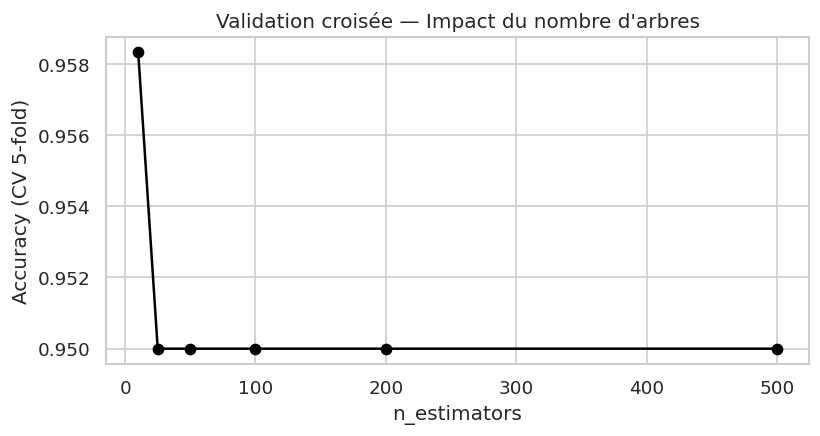

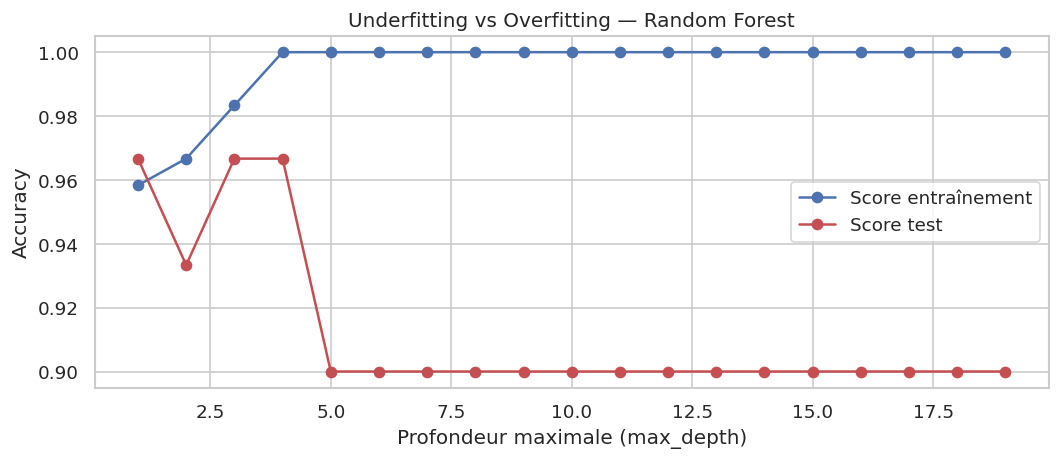

In [ ]:
# Impact du nombre d'arbres mesuré par validation croisée 5-fold
n_estimators_range = [10, 25, 50, 100, 200, 500]
scores_cv = []

for n in n_estimators_range:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    cv = cross_val_score(m, X_train_sc, y_train, cv=5, scoring="accuracy")
    scores_cv.append(cv.mean())
    print(f"n_estimators={n:4d} → CV accuracy : {cv.mean()*100:.1f}% (±{cv.std()*100:.1f}%)")

plt.figure(figsize=(7, 3.8))
plt.plot(n_estimators_range, scores_cv, "o-", color="black")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy (CV 5-fold)")
plt.title("Validation croisée — Impact du nombre d'arbres")
plt.grid(True)
plt.tight_layout()

# Livrable (image)
plt.savefig(OUTPUT_DIR / "cv_n_estimators.png", bbox_inches="tight")
plt.show()

# Courbe overfitting : score train vs score test selon la profondeur
profondeurs = range(1, 20)
scores_train = []
scores_test = []

for d in profondeurs:
    m = RandomForestClassifier(n_estimators=50, max_depth=d, random_state=42)
    m.fit(X_train_sc, y_train)
    scores_train.append(m.score(X_train_sc, y_train))
    scores_test.append(m.score(X_test_sc, y_test))

plt.figure(figsize=(9, 4))
plt.plot(profondeurs, scores_train, "b-o", label="Score entraînement")
plt.plot(profondeurs, scores_test, "r-o", label="Score test")
plt.xlabel("Profondeur maximale (max_depth)")
plt.ylabel("Accuracy")
plt.title("Underfitting vs Overfitting — Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Livrable (image)
plt.savefig(OUTPUT_DIR / "overfitting.png", bbox_inches="tight")
plt.show()


## Étape 5 — Explicabilité SHAP

### Questions du TP et réponses (basées sur le summary plot SHAP)

- **(1) Quelle variable est la plus déterminante selon SHAP ? Est-ce cohérent avec votre intuition ?**  
  Globalement, **petal_width** (largeur du pétale) ressort comme la variable la plus influente, très proche de **petal_length**. Oui, c’est cohérent avec le *pairplot* : les variables de pétales séparent le mieux les espèces.

- **(2) Différence entre l’importance sklearn (MDI) et l’importance SHAP ?**  
  L’importance **MDI** (sklearn) mesure une baisse moyenne d’impureté dans les arbres, mais peut être **biaisée** (corrélations, structure de l’arbre). **SHAP** attribue une contribution par variable **pour chaque prédiction** (explicabilité locale) et se moyenne ensuite pour une importance globale (plus proche d’une explication causale du modèle).

- **(3) Pourquoi l’explicabilité est-elle cruciale dans un contexte réglementé (médical, crédit bancaire) ?**  
  Parce qu’on doit **justifier** les décisions (audits, conformité), détecter les biais, et donner des raisons compréhensibles aux utilisateurs/clients. Sans explicabilité, on peut prendre des décisions à fort impact sans contrôle ni transparence.


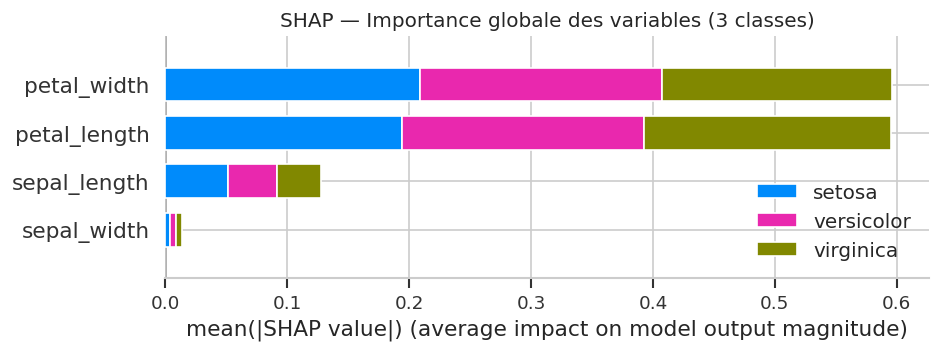

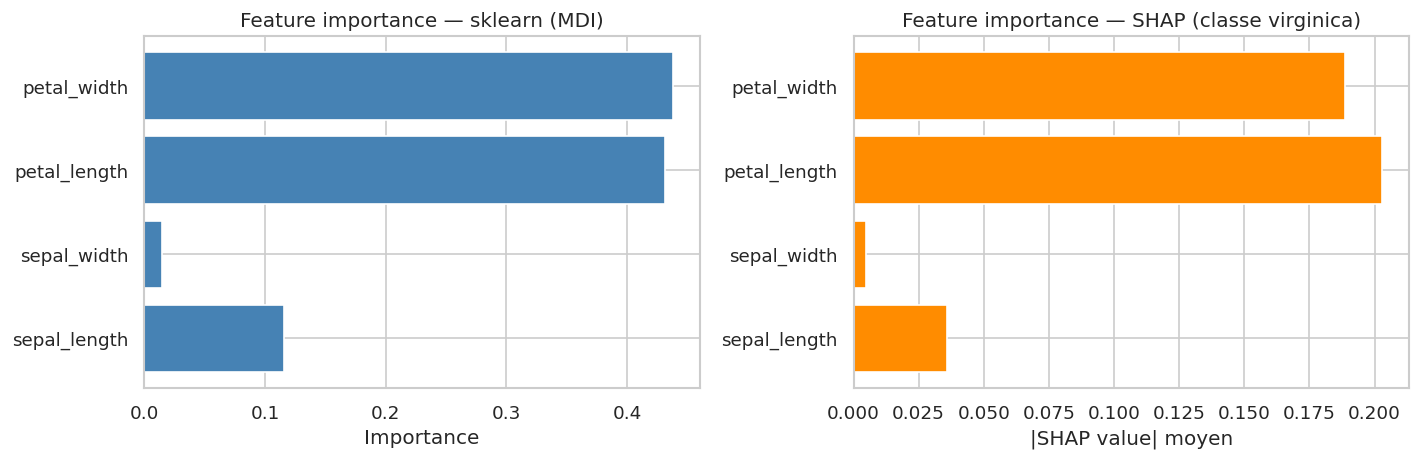

In [ ]:
# Modèle final (paramètres du TP)
rf_final = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_final.fit(X_train_sc, y_train)

# Explainer SHAP adapté aux forêts aléatoires
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_sc)

# Summary plot global (importance par classe, vue en barres)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=feature_names,
    class_names=list(le.classes_),
    plot_type="bar",
    show=False,
)
plt.title("SHAP — Importance globale des variables (3 classes)")
plt.tight_layout()

# Livrable (image)
plt.savefig(OUTPUT_DIR / "shap_summary.png", bbox_inches="tight")
plt.show()

# Comparaison : feature importance sklearn (MDI) vs SHAP (classe virginica)
importances_sklearn = rf_final.feature_importances_

# Compatibilité SHAP: shap_values peut être une liste (1 tableau par classe) ou un tenseur (n, p, classes)
if isinstance(shap_values, list):
    importances_shap = np.abs(shap_values[2]).mean(axis=0)  # index 2 = virginica
else:
    importances_shap = np.abs(shap_values[:, :, 2]).mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh(feature_names, importances_sklearn, color="steelblue")
ax1.set_title("Feature importance — sklearn (MDI)")
ax1.set_xlabel("Importance")

ax2.barh(feature_names, importances_shap, color="darkorange")
ax2.set_title("Feature importance — SHAP (classe virginica)")
ax2.set_xlabel("|SHAP value| moyen")

plt.tight_layout()

# Livrable (image)
plt.savefig(OUTPUT_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()


## Étape 6 — Debrief : 3 insights clés

### Insight 1 — Performance
**Observation** → Sur ce split, le **Decision Tree** (baseline) atteint **96,7%** d’accuracy, contre **93,3%** pour le Random Forest (paramètres du TP).  
**Explication** → Un modèle plus complexe n’est pas automatiquement meilleur : avec peu de données et des hyperparamètres non optimisés, la forêt peut ne pas exploiter son potentiel (et introduire de la variance).  
**Implication pratique** → Toujours comparer à une **baseline** ; si le gain est faible (ou négatif), simplifier le modèle ou faire du **tuning** avant de complexifier.

### Insight 2 — Overfitting / Généralisation
**Observation** → À partir de **max_depth ≈ 5**, le score entraînement devient nettement supérieur au score test (écart jusqu’à ~**0,10**).  
**Explication** → L’overfitting apparaît quand le modèle apprend trop finement les particularités du train (bruit), ce qui dégrade la généralisation.  
**Implication pratique** → Contrôler la complexité (ex. `max_depth`), utiliser la **validation croisée** et choisir des hyperparamètres qui maximisent la performance **hors-échantillon**.

### Insight 3 — Explicabilité
**Observation** → Le SHAP summary plot montre que **petal_width** (et très proche **petal_length**) domine l’influence globale des prédictions.  
**Explication** → C’est cohérent avec l’EDA : les variables liées au pétale séparent fortement les espèces, alors que `sepal_width` apporte peu d’information discriminante.  
**Implication pratique** → En contexte réglementé (médical, crédit), l’explicabilité est essentielle pour **justifier** une décision, auditer des biais et rendre le modèle acceptable.
